# Gold through war and inflation

**pyportfolios.com research note** · GLD, SPY, TIP, IEF daily, Nov 2004 – Dec 2024 · NumPy · pandas · matplotlib · yfinance

An empirical read of the two stories gold is sold on — the inflation hedge and the
crisis hedge. We test three things on twenty years of real data:

1. gold versus the **real yield** (proxied by the TIP ETF, whose price moves inversely
   to 10y real yields),
2. gold's return across **inflation regimes** (a TIP-minus-IEF breakeven proxy), and
3. an **event study** around the 2008 GFC, the 2020 COVID shock and the 2022 invasion
   of Ukraine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)

## 1 · Data: GLD, SPY, TIP, IEF

GLD from its November 2004 inception. TIP (10y-ish TIPS ETF) is the tradable inverse
of the real yield; IEF (7–10y nominal Treasuries) lets us difference out a breakeven
proxy.

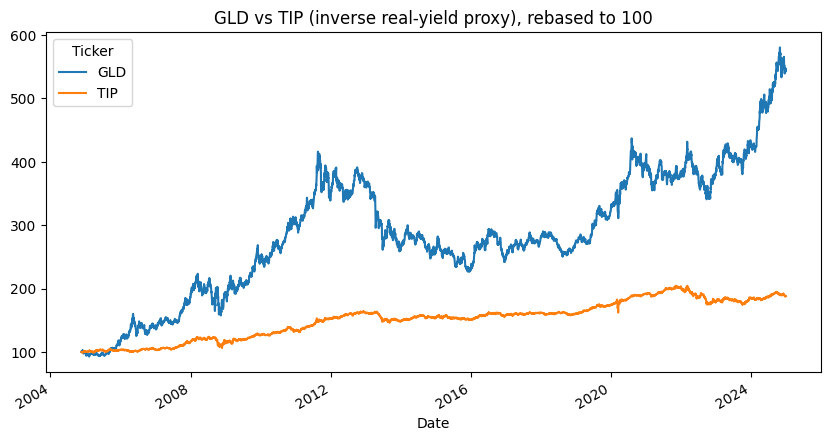

In [2]:
px = yf.download(["GLD", "SPY", "TIP", "IEF"], start="2004-11-18", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].dropna()
(100 * px / px.iloc[0])[["GLD", "TIP"]].plot(
    title="GLD vs TIP (inverse real-yield proxy), rebased to 100");

## 2 · Gold tracks real yields

Gold pays no coupon, so its opportunity cost is the real yield. TIP's price rises when
real yields fall — so if the real-yield story is right, monthly gold returns should be
strongly *positively* related to TIP returns.

beta (gold on TIP)  1.28
corr                0.45   R^2 0.20


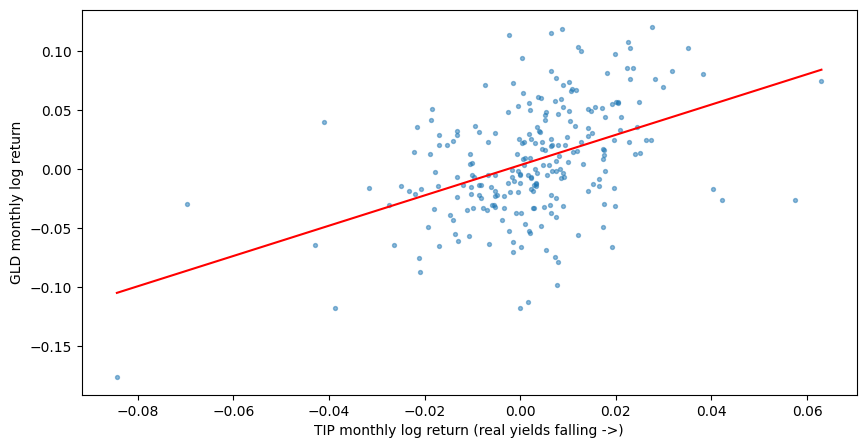

In [3]:
mret = np.log(px.resample("ME").last()).diff().dropna()
g, t = mret["GLD"], mret["TIP"]

beta = np.polyfit(t, g, 1)[0]
corr = g.corr(t)
print(f"beta (gold on TIP)  {beta:.2f}")
print(f"corr                {corr:.2f}   R^2 {corr**2:.2f}")
plt.scatter(t, g, s=8, alpha=0.5)
grid = np.linspace(t.min(), t.max(), 50)
plt.plot(grid, np.polyfit(t, g, 1) @ [grid, np.ones_like(grid)], "r")
plt.xlabel("TIP monthly log return (real yields falling ->)")
plt.ylabel("GLD monthly log return");
plt.show()

## 3 · The inflation hedge is conditional

Proxy inflation expectations by the trailing-12m TIP-minus-IEF relative return (a
tradable breakeven). Split months into high/low inflation-expectation regimes, then
split the high-inflation months by whether real yields were falling (TIP up) or
rising. Gold's celebrated hedge should only show up in one cell.

In [4]:
be = (mret["TIP"] - mret["IEF"]).rolling(12).sum().dropna()
g_al, t_al = g.loc[be.index], t.loc[be.index]
hi, fall = be > be.median(), t_al > 0

for name, sel in [("high infl, falling real yields", hi & fall),
                  ("high infl, rising real yields",  hi & ~fall),
                  ("low / stable inflation",         ~hi)]:
    print(f"{name:32s} n={sel.sum():3d}  gold {g_al[sel].mean()*12:+.1%} ann.")

high infl, falling real yields   n= 71  gold +24.6% ann.
high infl, rising real yields    n= 44  gold -15.3% ann.
low / stable inflation           n=115  gold +7.9% ann.


## 4 · What war (and crisis) adds

Event study: rebase GLD to 100 at each shock onset and trace -10 to +60 trading days.
Lehman (2008-09-15), the COVID equity peak (2020-02-19), the invasion of Ukraine
(2022-02-24).

GFC / Lehman   +5d +15.0%  +20d +5.7%  +60d -1.6%
COVID          +5d +1.4%  +20d -7.3%  +60d +7.4%
Ukraine        +5d +2.1%  +20d +3.4%  +60d -2.9%


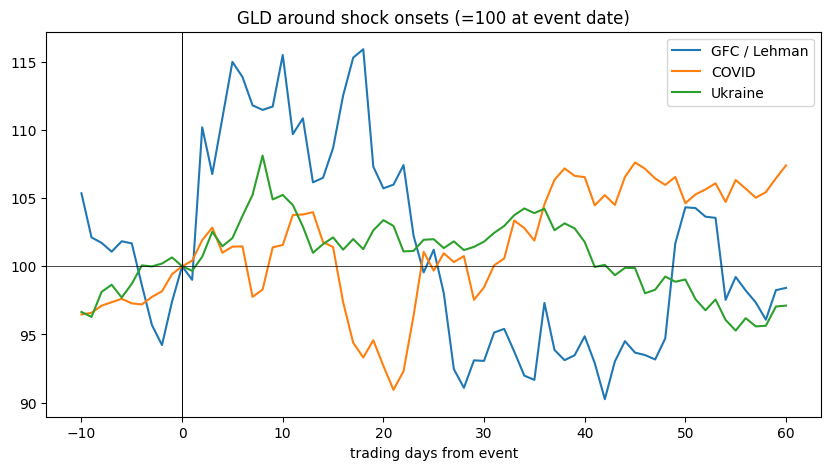

In [5]:
events = {"GFC / Lehman": "2008-09-15",
          "COVID": "2020-02-19",
          "Ukraine": "2022-02-24"}
gld = px["GLD"]

for name, d0 in events.items():
    i = gld.index.searchsorted(pd.Timestamp(d0))
    w = 100 * gld.iloc[i-10:i+61] / gld.iloc[i]
    plt.plot(range(-10, len(w)-10), w.values, label=name)
    print(f"{name:14s} +5d {w.iloc[15]/100-1:+.1%}  +20d {w.iloc[30]/100-1:+.1%}"
          f"  +60d {w.iloc[70]/100-1:+.1%}")
plt.axvline(0, color="k", lw=0.7); plt.axhline(100, color="k", lw=0.5)
plt.legend(); plt.title("GLD around shock onsets (=100 at event date)")
plt.xlabel("trading days from event");
plt.show()

## 5 · Diversifier, not doomsday insurance

The rolling one-year correlation of daily gold and equity returns hovers near zero —
that, not a guaranteed crisis payoff, is the durable portfolio property.

mean +0.05   range [-0.35, +0.44]
GLD CAGR 8.8%   SPY CAGR 10.3%


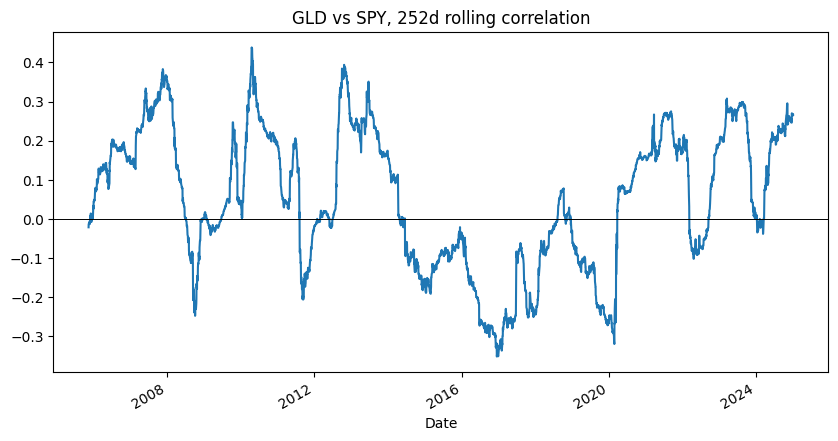

In [6]:
dret = np.log(px).diff().dropna()
rc = dret["GLD"].rolling(252).corr(dret["SPY"]).dropna()
rc.plot(title="GLD vs SPY, 252d rolling correlation")
plt.axhline(0, color="k", lw=0.7)
print(f"mean {rc.mean():+.2f}   range [{rc.min():+.2f}, {rc.max():+.2f}]")

years = (px.index[-1] - px.index[0]).days / 365.25
print(f"GLD CAGR {(px['GLD'].iloc[-1]/px['GLD'].iloc[0])**(1/years)-1:.1%}"
      f"   SPY CAGR {(px['SPY'].iloc[-1]/px['SPY'].iloc[0])**(1/years)-1:.1%}")

## Takeaways

- Gold's strongest empirical relationship is with the **real yield** (via TIP), not
  headline inflation.
- The inflation hedge is **regime-dependent**: it pays when inflation expectations are
  high *and* real yields are falling, and disappoints when central banks push real
  yields up.
- The conflict/crisis premium is real but **transient** — a fast bid measured in days
  to weeks, then real-yield dynamics reassert control.
- The durable allocation case is the ~zero equity correlation, i.e. diversification —
  not a set-and-forget insurance policy.

*© pyportfolios.com — runnable companion to the research note. Data: Yahoo Finance via yfinance.*